In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Colab Ready")

Colab Ready


In [ ]:
import numpy as np

X_train = np.load("X_train.npy")
X_test = np.load("X_test.npy")
y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'X_train.npy'

In [ ]:
import numpy as np

print("Files loaded successfully")

X_train = np.load("X_train.npy")
X_test = np.load("X_test.npy")
y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Files loaded successfully


FileNotFoundError: [Errno 2] No such file or directory: 'X_train.npy'

In [ ]:
!ls

sample_data


In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
import os

print(os.listdir('/content'))

['.config', 'sample_data']


In [ ]:
%ls /content

sample_data/


In [ ]:
import numpy as np

X_test = np.load("/X_test.npy")
print(X_test.shape)

(235, 6, 6)


In [ ]:
import numpy as np

X_train = np.load("/X_train.npy")
X_test = np.load("/X_test.npy")
y_train = np.load("/y_train.npy")
y_test = np.load("/y_test.npy")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (939, 6, 6)
X_test shape: (235, 6, 6)
y_train shape: (939,)
y_test shape: (235,)


In [ ]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Flattened X_train:", X_train_flat.shape)
print("Flattened X_test:", X_test_flat.shape)

Flattened X_train: (939, 36)
Flattened X_test: (235, 36)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_flat, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
from sklearn.metrics import accuracy_score

y_pred = rf.predict(X_test_flat)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9787234042553191


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       190
           1       0.95      0.93      0.94        45

    accuracy                           0.98       235
   macro avg       0.97      0.96      0.97       235
weighted avg       0.98      0.98      0.98       235



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[188   2]
 [  3  42]]


In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test_flat)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.9971929824561404


In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": range(36),
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

    Feature  Importance
24       24    0.143788
12       12    0.112652
30       30    0.099712
21       21    0.096253
27       27    0.049489
34       34    0.049087
28       28    0.039710
7         7    0.036193
17       17    0.035684
18       18    0.034541


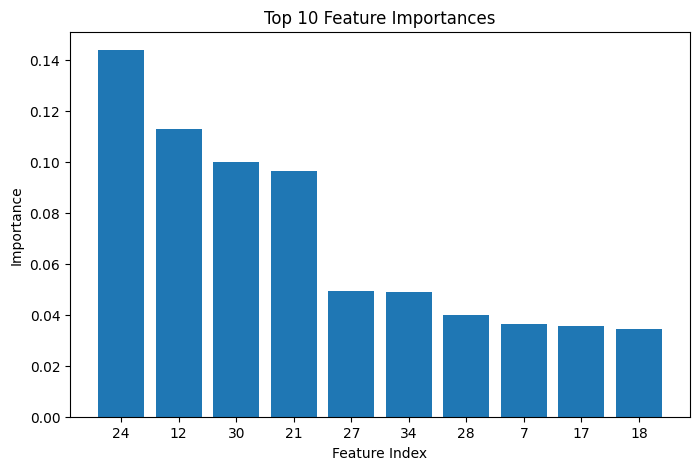

In [ ]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(8,5))
plt.bar(top10["Feature"].astype(str),
        top10["Importance"])

plt.title("Top 10 Feature Importances")
plt.xlabel("Feature Index")
plt.ylabel("Importance")

plt.show()

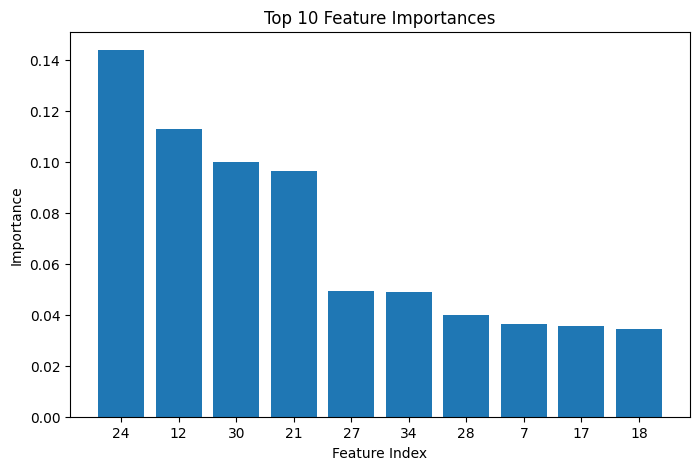

Graph saved successfully!


In [ ]:
plt.figure(figsize=(8,5))
plt.bar(top10["Feature"].astype(str),
        top10["Importance"])

plt.title("Top 10 Feature Importances")
plt.xlabel("Feature Index")
plt.ylabel("Importance")

plt.savefig("rf_feature_importance.png",
            bbox_inches="tight",
            dpi=300)

plt.show()

print("Graph saved successfully!")

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "ROC-AUC"
    ],
    "Value": [
        accuracy,
        0.9971929824561404
    ]
})

results

,Metric,Value
0,Accuracy,0.978723
1,ROC-AUC,0.997193


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy,
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        0.9971929824561404
    ]
})

final_results

,Metric,Value
0,Accuracy,0.978723
1,Precision,0.954545
2,Recall,0.933333
3,F1-Score,0.943820
4,ROC-AUC,0.997193


In [ ]:
final_results.to_csv("random_forest_results.csv", index=False)

print("Results saved successfully!")

Results saved successfully!


In [ ]:
import joblib

joblib.dump(rf, "random_forest_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import os

for file in os.listdir():
    if file.endswith((".png", ".csv", ".pkl")):
        print(file)

random_forest_model.pkl
random_forest_results.csv
rf_feature_importance.png


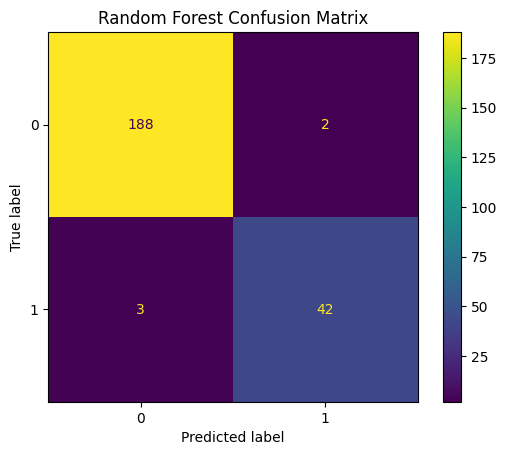

Confusion matrix saved!


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Random Forest Confusion Matrix")
plt.savefig("rf_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved!")

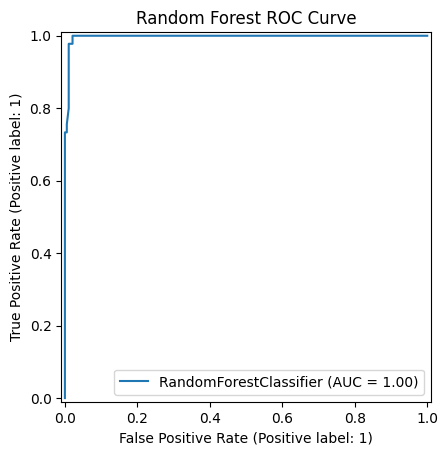

ROC curve saved!


In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(rf, X_test_flat, y_test)

plt.title("Random Forest ROC Curve")
plt.savefig("rf_roc_curve.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

print("ROC curve saved!")

In [ ]:
feature_names = []

for t in range(1, 7):
    feature_names.extend([
        f"cycle_length_t{t}",
        f"cramp_score_t{t}",
        f"mood_score_t{t}",
        f"flow_intensity_t{t}",
        f"sleep_quality_t{t}",
        f"stress_score_t{t}"
    ])

feature_importance_named = feature_importance.copy()

feature_importance_named["Feature"] = (
    feature_importance_named["Feature"]
    .apply(lambda x: feature_names[x])
)

print(feature_importance_named.head(10))

              Feature  Importance
24    cycle_length_t5    0.143788
12    cycle_length_t3    0.112652
30    cycle_length_t6    0.099712
21  flow_intensity_t4    0.096253
27  flow_intensity_t5    0.049489
34   sleep_quality_t6    0.049087
28   sleep_quality_t5    0.039710
7      cramp_score_t2    0.036193
17    stress_score_t3    0.035684
18    cycle_length_t4    0.034541


In [ ]:
feature_importance_named.head(10).to_csv(
    "rf_top10_features.csv",
    index=False
)

print("Top 10 feature table saved!")

Top 10 feature table saved!


In [ ]:
paper_results = {
    "Model": "Random Forest",
    "Training Samples": 939,
    "Testing Samples": 235,
    "Accuracy": accuracy,
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1_Score": f1_score(y_test, y_pred),
    "ROC_AUC": auc
}

import pandas as pd

paper_results_df = pd.DataFrame([paper_results])

paper_results_df.to_csv(
    "rf_paper_results.csv",
    index=False
)

paper_results_df

,Model,Training Samples,Testing Samples,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Random Forest,939,235,0.978723,0.954545,0.933333,0.94382,0.997193


In [ ]:
import os

for file in os.listdir():
    if file.endswith((".png", ".csv", ".pkl")):
        print(file)

random_forest_model.pkl
random_forest_results.csv
rf_feature_importance.png
rf_roc_curve.png
rf_top10_features.csv
rf_confusion_matrix.png
rf_paper_results.csv
